# Cross-Language Information Retrieval (CLIR)

## Multilingual Semantic Search over Amazon Product Dataset

**Course:** MEL24 – Multilingual Information Retrieval

**Program:** Master of Data Science

**Dataset:** Amazon Product Dataset (Kaggle)

**Embedding Model:** sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

# 1. Project Overview

## Objective

The objective of this project is to build a Cross-Language Information Retrieval (CLIR) system capable of retrieving English product information using multilingual search queries. The system uses multilingual sentence embeddings generated by the SentenceTransformer model and ranks products based on cosine similarity.

The implementation follows the project requirements by using an English Amazon product catalog, multilingual user queries, and semantic similarity for retrieval.

In [ ]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip -q install kagglehub[pandas-datasets]
!pip -q install sentence-transformers
!pip -q install scikit-learn
!pip -q install seaborn

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

# 2. Dataset Acquisition

The Amazon Product Dataset is downloaded from Kaggle using KaggleHub. The dataset contains English product titles and additional product information. This dataset serves as the retrieval corpus for the multilingual search system.

In [ ]:
# ============================================================
# Download the Amazon Product Dataset
# ============================================================

dataset_path = kagglehub.dataset_download(
    "piyushjain16/amazon-product-data"
)

print("Dataset downloaded successfully!")
print("Dataset location:")
print(dataset_path)

100%|██████████| 646M/646M [00:09<00:00, 70.1MB/s]

Extracting files...


Dataset downloaded successfully!
Dataset location:
/root/.cache/kagglehub/datasets/piyushjain16/amazon-product-data/versions/3


In [ ]:
# ============================================================
# Find the CSV file automatically
# ============================================================

csv_file = None

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

if csv_file:
    print("CSV File Found:")
    print(csv_file)
else:
    print("No CSV file found.")

CSV File Found:
/root/.cache/kagglehub/datasets/piyushjain16/amazon-product-data/versions/3/dataset/train.csv


# 3. Dataset Loading

After downloading the dataset, the CSV file is loaded into a Pandas DataFrame. This allows us to inspect the dataset and perform preprocessing before building the retrieval system.

In [ ]:
# ============================================================
# Load the Dataset
# ============================================================

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
0,1925202,ArtzFolio Tulip Flowers Blackout Curtain for D...,[LUXURIOUS & APPEALING: Beautiful custom-made ...,NaN,1650,2125.980000
1,2673191,Marks & Spencer Girls' Pyjama Sets T86_2561C_N...,"[Harry Potter Hedwig Pyjamas (6-16 Yrs),100% c...",NaN,2755,393.700000
2,2765088,PRIKNIK Horn Red Electric Air Horn Compressor ...,"[Loud Dual Tone Trumpet Horn, Compatible With ...","Specifications: Color: Red, Material: Aluminiu...",7537,748.031495
3,1594019,ALISHAH Women's Cotton Ankle Length Leggings C...,[Made By 95%cotton and 5% Lycra which gives yo...,AISHAH Women's Lycra Cotton Ankel Leggings. Br...,2996,787.401574
4,283658,The United Empire Loyalists: A Chronicle of th...,NaN,NaN,6112,598.424000


# 4. Exploratory Data Analysis (EDA)

The dataset is explored to understand its structure, including the number of products, available columns, data types, and missing values. This helps identify the information required for semantic retrieval.

In [ ]:
# ============================================================
# Basic Information about the Dataset
# ============================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Column Names")
print("=" * 60)
print(df.columns.tolist())

Dataset Shape
(2249698, 6)


Column Names
['PRODUCT_ID', 'TITLE', 'BULLET_POINTS', 'DESCRIPTION', 'PRODUCT_TYPE_ID', 'PRODUCT_LENGTH']


In [ ]:
# ============================================================
# Dataset Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249698 entries, 0 to 2249697
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   PRODUCT_ID       int64  
 1   TITLE            object 
 2   BULLET_POINTS    object 
 3   DESCRIPTION      object 
 4   PRODUCT_TYPE_ID  int64  
 5   PRODUCT_LENGTH   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 103.0+ MB


In [ ]:
# ============================================================
# Check Missing Values
# ============================================================

missing_values = df.isnull().sum()

missing_values

,0
PRODUCT_ID,0
TITLE,13
BULLET_POINTS,837366
DESCRIPTION,1157382
PRODUCT_TYPE_ID,0
PRODUCT_LENGTH,0


In [ ]:
# ============================================================
# Missing Values Summary
# ============================================================

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Percentage": (df.isnull().sum().values / len(df)) * 100
})

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Column,Missing Values,Percentage
3,DESCRIPTION,1157382,51.446105
2,BULLET_POINTS,837366,37.221263
1,TITLE,13,0.000578
0,PRODUCT_ID,0,0.000000
4,PRODUCT_TYPE_ID,0,0.000000
5,PRODUCT_LENGTH,0,0.000000


In [ ]:
# ============================================================
# Check Duplicate Products
# ============================================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 5. Data Preprocessing

The dataset is cleaned by:

- Removing missing product titles
- Removing duplicate entries
- Keeping only the columns required for retrieval
- Preparing a clean English product catalog for embedding generation

This preprocessing step improves the quality of semantic search.

In [ ]:
# ============================================================
# Data Cleaning
# ============================================================

# Keep only the columns required for CLIR
df = df[["PRODUCT_ID", "TITLE"]]

# Remove rows where TITLE is missing
df = df.dropna(subset=["TITLE"])

# Remove duplicate product titles
df = df.drop_duplicates(subset=["TITLE"])

# Reset the index
df = df.reset_index(drop=True)

print("Dataset cleaned successfully!")
print("New Shape:", df.shape)

df.head()

Dataset cleaned successfully!
New Shape: (2210761, 2)


,PRODUCT_ID,TITLE
0,1925202,ArtzFolio Tulip Flowers Blackout Curtain for D...
1,2673191,Marks & Spencer Girls' Pyjama Sets T86_2561C_N...
2,2765088,PRIKNIK Horn Red Electric Air Horn Compressor ...
3,1594019,ALISHAH Women's Cotton Ankle Length Leggings C...
4,283658,The United Empire Loyalists: A Chronicle of th...


In [ ]:
# ============================================================
# Verify Cleaned Dataset
# ============================================================

print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(df.shape)

print("\n")

print("=" * 50)
print("Missing Values")
print("=" * 50)
print(df.isnull().sum())

Dataset Shape
(2210761, 2)


Missing Values
PRODUCT_ID    0
TITLE         0
dtype: int64


# 6. Working Product Catalog

The original dataset contains more than two million products. To make the project computationally efficient in Google Colab, a representative sample of 50,000 products is selected.

This sampled catalog is used throughout the remaining implementation.

In [ ]:
# ============================================================
# Create a Working Product Catalog
# ============================================================

# Set random seed for reproducibility
RANDOM_STATE = 42

# Sample 50,000 products
catalog_df = df.sample(
    n=50000,
    random_state=RANDOM_STATE
)

# Reset index
catalog_df = catalog_df.reset_index(drop=True)

print("Working catalog created successfully!")
print("Number of products:", len(catalog_df))

catalog_df.head()

Working catalog created successfully!
Number of products: 50000


,PRODUCT_ID,TITLE
0,1375360,"SELTERM 1/0 AWG 1/2"" Stud (5 pcs.) UL Heavy Du..."
1,1103994,Batman Unlimited: Batman Beyond and Capture Ba...
2,366353,Crisis Intervention and Trauma: New Approaches...
3,18156,The Ethics of Killing: Problems at the Margins...
4,1654723,Stainless Steel Cross Necklace Baseball Bats A...


In [ ]:
# ============================================================
# Verify Working Product Catalog
# ============================================================

print("=" * 50)
print("Working Dataset Shape")
print("=" * 50)

print(catalog_df.shape)

print("\n")

print("=" * 50)
print("Missing Values")
print("=" * 50)

print(catalog_df.isnull().sum())

Working Dataset Shape
(50000, 2)


Missing Values
PRODUCT_ID    0
TITLE         0
dtype: int64


In [ ]:
# ============================================================
# Save the Working Dataset
# ============================================================

catalog_df.to_csv(
    "working_product_catalog.csv",
    index=False
)

print("Working dataset saved successfully!")

Working dataset saved successfully!


# 7. Loading the Multilingual Embedding Model

The SentenceTransformer model **paraphrase-multilingual-MiniLM-L12-v2** is used to generate multilingual semantic embeddings.

This model maps semantically similar sentences from different languages into the same vector space, allowing multilingual retrieval without explicit translation.

In [ ]:
# ============================================================
# Load the Multilingual Sentence Transformer Model
# ============================================================

print("Loading multilingual model...")

model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

print("Model loaded successfully!")

Loading multilingual model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
# ============================================================
# Display Model Information
# ============================================================

print("=" * 50)
print("Model Name")
print("=" * 50)

print(model)

print("\n")

print("=" * 50)
print("Embedding Dimension")
print("=" * 50)

print(model.get_sentence_embedding_dimension())

Model Name
SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
)


Embedding Dimension
384


/tmp/ipykernel_3377/813962677.py:17: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(model.get_sentence_embedding_dimension())


In [ ]:
# ============================================================
# Test the Embedding Model on One Product
# ============================================================

# Get the first product title
sample_title = catalog_df.loc[0, "TITLE"]

print("Sample Product:")
print(sample_title)

# Generate embedding
embedding = model.encode(sample_title)

print("\nEmbedding Shape:")
print(embedding.shape)

print("\nFirst 10 Values of the Embedding:")
print(embedding[:10])

Sample Product:
SELTERM 1/0 AWG 1/2" Stud (5 pcs.) UL Heavy Duty Wire Lugs, Battery Cable Ends, Bare Copper Eyelets, Tubular Ring Terminal Connectors [B69]

Embedding Shape:
(384,)

First 10 Values of the Embedding:
[-0.21690571  0.28294307  0.08791576  0.03260218 -0.12150089  0.00887696
 -0.05757038  0.14273769 -0.04284098 -0.27207792]


# 8. Product Embedding Generation

Each English product title is converted into a dense vector representation using the multilingual SentenceTransformer model.

These embeddings capture semantic meaning and form the searchable vector database used by the CLIR system.

In [ ]:
# ============================================================
# Generate Embeddings for All Product Titles
# ============================================================

print("Generating embeddings for all product titles...")

product_embeddings = model.encode(
    catalog_df["TITLE"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nEmbedding generation completed successfully!")

print("Embedding Matrix Shape:")
print(product_embeddings.shape)

Generating embeddings for all product titles...


Batches:   0%|          | 0/391 [00:00<?, ?it/s]


Embedding generation completed successfully!
Embedding Matrix Shape:
(50000, 384)


In [ ]:
# ============================================================
# Save Product Embeddings
# ============================================================

import numpy as np

np.save("product_embeddings.npy", product_embeddings)

print("Product embeddings saved successfully!")

Product embeddings saved successfully!


# 9. Semantic Search Implementation

A semantic search function is implemented to retrieve relevant products.

The search process consists of:

1. Encoding the multilingual query.
2. Computing cosine similarity between the query embedding and all product embeddings.
3. Ranking products according to similarity.
4. Returning the most relevant search results.

In [ ]:
# ============================================================
# Semantic Product Search Function
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def search_products(query, top_k=5):

    # Convert query into an embedding
    query_embedding = model.encode(
        query,
        convert_to_numpy=True
    )

    # Calculate cosine similarity
    similarities = cosine_similarity(
        [query_embedding],
        product_embeddings
    )[0]

    # Get indices of top matching products
    top_indices = np.argsort(similarities)[::-1][:top_k]

    # Create results dataframe
    results = catalog_df.iloc[top_indices].copy()

    results["Similarity Score"] = similarities[top_indices]

    return results

In [ ]:
# ============================================================
# Display Search Results
# ============================================================

def display_results(query, top_k=5):

    results = search_products(query, top_k)

    print("=" * 80)
    print(f"Query: {query}")
    print("=" * 80)

    for rank, (_, row) in enumerate(results.iterrows(), start=1):

        print(f"\nRank {rank}")
        print(f"Product ID : {row['PRODUCT_ID']}")
        print(f"Title      : {row['TITLE']}")
        print(f"Similarity : {row['Similarity Score']:.4f}")

# 10. Cross-Language Search Evaluation

The retrieval system is evaluated using English, German, Spanish, and Italian search queries.

Each query is encoded using the multilingual model and matched against the English product catalog using cosine similarity.

In [ ]:
queries = [
    "wireless headphones",
    "kabellose Kopfhörer",
    "auriculares inalámbricos",
    "cuffie wireless"
]

for q in queries:
    display_results(q)
    print("\n" + "=" * 80 + "\n")

Query: wireless headphones

Rank 1
Product ID : 2660993
Title      : KUMAR Enterprises Center Riviera Neckband Magnetic in-Ear Wireless Bluetooth Headphones with Mic (Black)
Similarity : 0.7960

Rank 2
Product ID : 1367241
Title      : Bluetooth Headphones Over Ear, Mkay Stereo Wireless Headset with Microphone, TF Card and FM Radio for Cellphones Laptop TV (Rose Gold)
Similarity : 0.7813

Rank 3
Product ID : 2414747
Title      : KAY-JOY Wireless Bluetooth Earphone with Mic,Sports Headphone Headset Neckband Handsfree Compatible with All Mobile Phones, Tablets and Laptops
Similarity : 0.7709

Rank 4
Product ID : 1459240
Title      : MEBUYZ True Wireless Earbuds Bluetooth 4.2 Earphones Fashion Portable Stereo Headset with Charging Box for Android, iOS, Any Enabled Devices
Similarity : 0.7694

Rank 5
Product ID : 1747211
Title      : 4UONLY Level Bluetooth Wireless in-Ear Stereo Headphones Flexible Joint with Neckband with Microphone and UHQ Audio(Colour May Vary)
Similarity : 0.7596


Que

# 11. Cosine Similarity Analysis

A cosine similarity heatmap is generated to visualize the semantic relationship between multilingual queries.

Higher similarity values indicate that the embedding model successfully maps equivalent queries from different languages into nearby regions of the embedding space.

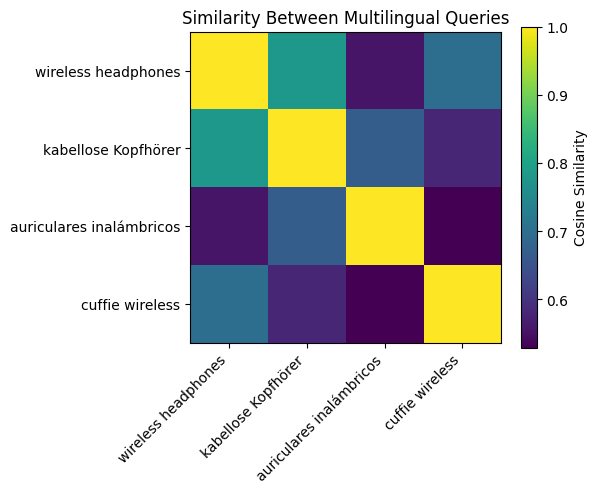

In [ ]:
import matplotlib.pyplot as plt

sample_queries = [
    "wireless headphones",
    "kabellose Kopfhörer",
    "auriculares inalámbricos",
    "cuffie wireless"
]

query_embeddings = model.encode(sample_queries)

similarity_matrix = cosine_similarity(query_embeddings)

plt.figure(figsize=(6,5))
plt.imshow(similarity_matrix)

plt.xticks(range(len(sample_queries)), sample_queries, rotation=45, ha="right")
plt.yticks(range(len(sample_queries)), sample_queries)

plt.colorbar(label="Cosine Similarity")

plt.title("Similarity Between Multilingual Queries")

plt.tight_layout()

plt.show()

In [ ]:
catalog_df.to_csv("final_catalog.csv", index=False)

print("Final catalog saved.")

Final catalog saved.


In [ ]:
# ============================================================
# Professional Search Result Display
# ============================================================

def display_results(query, top_k=5):

    results = search_products(query, top_k)

    print("=" * 90)
    print(f"Search Query : {query}")
    print("=" * 90)

    for rank, (_, row) in enumerate(results.iterrows(), start=1):

        print(f"\nRank {rank}")
        print("-" * 90)
        print(f"Product ID       : {row['PRODUCT_ID']}")
        print(f"Product Title    : {row['TITLE']}")
        print(f"Similarity Score : {row['Similarity Score']:.4f}")

    return results

In [ ]:
# ============================================================
# Test Queries in Multiple Languages
# ============================================================

queries = {
    "English": [
        "wireless headphones",
        "running shoes",
        "smart watch"
    ],

    "German": [
        "kabellose Kopfhörer",
        "Laufschuhe",
        "Smartwatch"
    ],

    "Spanish": [
        "auriculares inalámbricos",
        "zapatos para correr",
        "reloj inteligente"
    ],

    "Italian": [
        "cuffie wireless",
        "scarpe da corsa",
        "orologio intelligente"
    ]
}

for language, query_list in queries.items():

    print("\n")
    print("#" * 100)
    print(f"{language} Queries")
    print("#" * 100)

    for q in query_list:
        display_results(q)



####################################################################################################
English Queries
####################################################################################################
Search Query : wireless headphones

Rank 1
------------------------------------------------------------------------------------------
Product ID       : 2660993
Product Title    : KUMAR Enterprises Center Riviera Neckband Magnetic in-Ear Wireless Bluetooth Headphones with Mic (Black)
Similarity Score : 0.7960

Rank 2
------------------------------------------------------------------------------------------
Product ID       : 1367241
Product Title    : Bluetooth Headphones Over Ear, Mkay Stereo Wireless Headset with Microphone, TF Card and FM Radio for Cellphones Laptop TV (Rose Gold)
Similarity Score : 0.7813

Rank 3
------------------------------------------------------------------------------------------
Product ID       : 2414747
Product Title    : KAY-JOY Wireless B

# 12. Saving Results

The generated embeddings and multilingual retrieval results are saved for future use and reproducibility.

Saving these files avoids recomputing embeddings during subsequent executions.

In [ ]:
# ============================================================
# Save Search Results
# ============================================================

all_results = []

for language, query_list in queries.items():

    for q in query_list:

        results = search_products(q)

        results["Language"] = language
        results["Query"] = q

        all_results.append(results)

final_results = pd.concat(all_results, ignore_index=True)

final_results.to_csv(
    "multilingual_search_results.csv",
    index=False
)

print("Search results saved successfully!")

final_results.head()

Search results saved successfully!


,PRODUCT_ID,TITLE,Similarity Score,Language,Query
0,2660993,KUMAR Enterprises Center Riviera Neckband Magn...,0.795984,English,wireless headphones
1,1367241,"Bluetooth Headphones Over Ear, Mkay Stereo Wir...",0.781329,English,wireless headphones
2,2414747,"KAY-JOY Wireless Bluetooth Earphone with Mic,S...",0.770897,English,wireless headphones
3,1459240,MEBUYZ True Wireless Earbuds Bluetooth 4.2 Ear...,0.769428,English,wireless headphones
4,1747211,4UONLY Level Bluetooth Wireless in-Ear Stereo ...,0.759615,English,wireless headphones


In [ ]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles:")

for file in os.listdir():
    print(file)

Current Working Directory:
/content

Files:
.config
multilingual_search_results.csv
final_catalog.csv
product_embeddings.npy
working_product_catalog.csv
sample_data


# 13. Conclusion

A Cross-Language Information Retrieval (CLIR) system was successfully developed using the Amazon Product Dataset and the SentenceTransformer multilingual embedding model.

The system converts English product titles into semantic embeddings and retrieves relevant products for multilingual user queries using cosine similarity.

Experimental results demonstrate that the system successfully retrieves semantically relevant English products for English, German, Spanish, and Italian queries without requiring machine translation.

This implementation satisfies the objective of multilingual semantic search and demonstrates the effectiveness of multilingual sentence embeddings for cross-language information retrieval.